In [1]:
%load_ext autoreload
import sys
from pathlib import Path
import networkx as nx
import numpy as np
import cvxpy as cp
import seaborn as sns
from scipy.linalg import eigh
import matplotlib.pyplot as plt
import scipy.linalg as sla
import pandas as pd

In [2]:
project_root = Path().resolve()
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [3]:
%autoreload 2    
from lib.graph_factory import GraphFactory, add_graph_plot, calc_graph_metrics
from lib.utils import rng, seed
from lib.config import BASE_CONF, LOGFILE, GLOBAL_SEED, NUM_NODES
from lib.metrics import effective_mixing

## Graph Examples

In [4]:
# Parameters
num_nodes = NUM_NODES
local_rng = rng('graphs-global')

In [5]:
target_pi = local_rng.dirichlet(np.full(num_nodes,1))

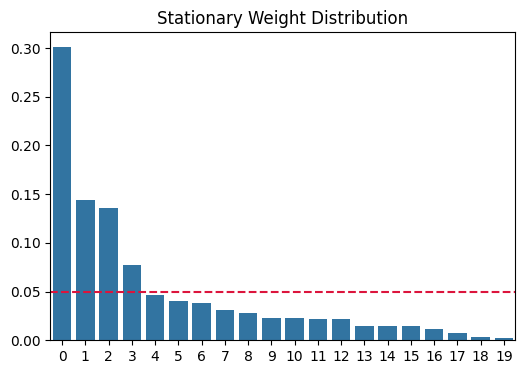

In [6]:
fig, ax = plt.subplots(1,1, figsize=(6,4))
sns.barplot(x=np.arange(num_nodes), y=np.sort(target_pi)[::-1], ax=ax)
ax.axhline(1/num_nodes, ls="--", color="crimson")
ax.set_title("Stationary Weight Distribution")
plt.show()

In [7]:
b = 5
gf = GraphFactory(num_nodes, b)
graph_args = {
    'ws_k': 6,
    'ws_p': 0.1,
    'rand_reg_deg':b,
    'geom_radius':0.3,
    'er_p':min(1.0, 3.0 * np.log(NUM_NODES) / NUM_NODES),
    'MH_target_pi':target_pi,
}
graphs = ['erdos-renyi', 'random-regular','watts-strogatz', 'geometric']
local_seed = 111

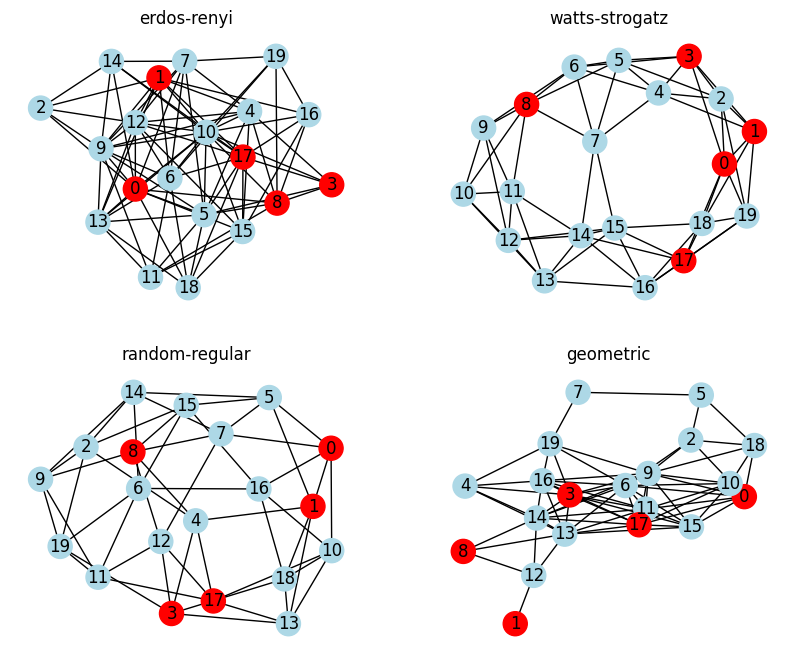

In [8]:
fig, ax = plt.subplots(2,2,figsize=(10,8))
rows=[]
for i, g in enumerate(graphs):
    metrics = {'graph_type':g}
    G,W,B,H = gf.create_graph(g, "MH", local_seed, **graph_args)
    metrics.update(calc_graph_metrics(W,b))
    add_graph_plot(G,B,ax[i%2,i//2])
    ax[i%2,i//2].set_title(g)
    rows.append(metrics)
plt.show()

In [9]:
pd.DataFrame(rows)

,graph_type,mu2,D_b,spectral_gap
0,erdos-renyi,0.312430,0.555988,0.687570
1,random-regular,0.252977,0.833333,0.747023
2,watts-strogatz,0.164738,0.738095,0.835262
3,geometric,0.079719,0.646368,0.920281


In [10]:
Wb, pi, lam = effective_mixing(W,H,0.1)
pi

array([0.06666667, 0.06666667, 0.06666667, 0.06666667, 0.06666667,
       0.06666667, 0.06666667, 0.06666667, 0.06666667, 0.06666667,
       0.06666667, 0.06666667, 0.06666667, 0.06666667, 0.06666667])

In [11]:
fig.savefig('graphs.png')